In [5]:
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.thetadata_pipeline.settings import get_settings

settings = get_settings()

In [7]:
strangle_trades = pl.read_parquet(get_settings().strategies_dir / 'SPY_strangle_trades.parquet')

# Capital gain

In [11]:
print(
    (strangle_trades['call_profit'] > 0).sum() / len(strangle_trades), strangle_trades['call_profit'].mean(), strangle_trades['call_profit'].sum(), '\n',
    (strangle_trades['put_profit'] > 0).sum() / len(strangle_trades), strangle_trades['put_profit'].mean(), strangle_trades['put_profit'].sum()
)

0.44323394495412843 0.032505733944954124 56.69 
 0.45126146788990823 0.06378440366972477 111.24


In [13]:
print(
    (strangle_trades['strangle_profit'] > 0).mean(),
    strangle_trades['strangle_profit'].mean(),
    strangle_trades['strangle_profit'].sum() / len(strangle_trades),
    strangle_trades['strangle_profit'].sum(),
    ((strangle_trades['put_profit'] > 0) & (strangle_trades['call_profit'] > 0)).sum() / len(strangle_trades)
)

0.669151376146789 0.09629013761467888 0.09629013761467888 167.92999999999995 0.07224770642201835


[-3913.  -845.  -338.   -39.    91.   195.   299.   455.   624.   884.
  4290.]
200000 418309.0


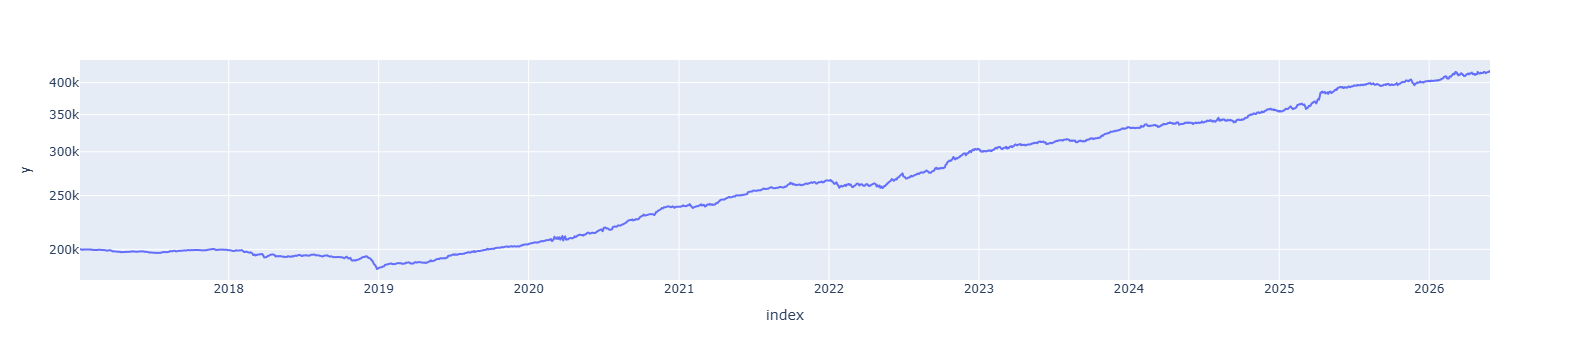

2017     -702.0
2018   -14378.0
2019    19253.0
2020    34060.0
2021    27326.0
2022    37544.0
2023    29744.0
2024    23348.0
2025    48256.0
2026    16224.0
Name: strangle_profit, dtype: float64
2017    100
2018    148
2019    156
2020    159
2021    157
2022    170
2023    250
2024    252
2025    250
2026    102
Name: strangle_profit, dtype: int64


In [23]:
invest: float = 200_000
position_margin: int = 15_100
positions = int(invest / position_margin)

capital = (strangle_trades['strangle_profit'] * 100 * positions)
print(np.quantile(capital, np.arange(0, 1.1, 0.1)))

capital[0] = capital[0] + invest
capital = capital.to_pandas().cumsum()
capital.index = strangle_trades['date'].to_list()
print(invest, capital.iloc[-1])

px.line(capital, y=capital, log_y=True).show()
print(
    capital.groupby(pd.to_datetime(capital.index).year).last() - capital.groupby(pd.to_datetime(capital.index).year).first()
)
print(capital.groupby(pd.to_datetime(capital.index).year).count())

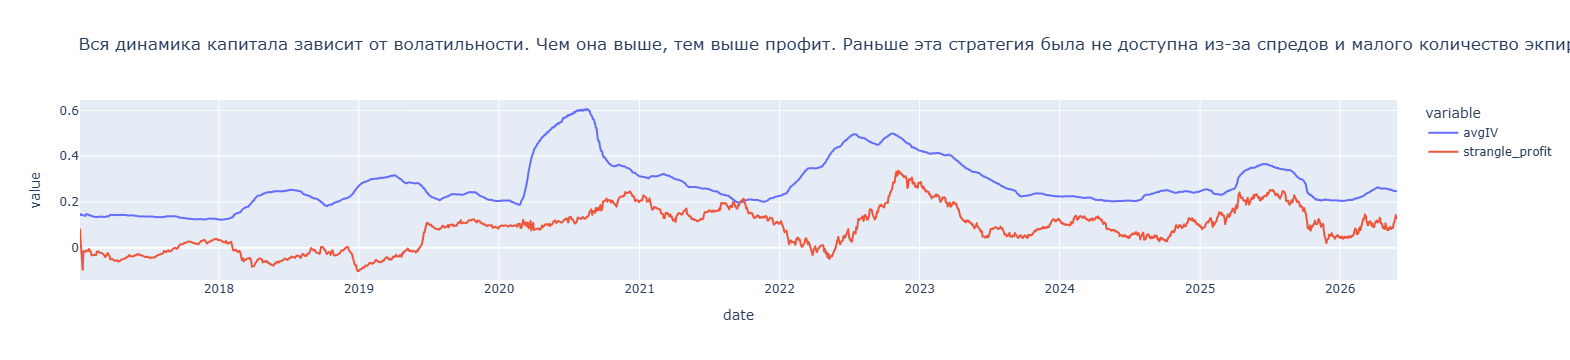

In [25]:
cur_df = strangle_trades\
    [['date', 'avgIV', 'strangle_profit']].to_pandas()\
    .set_index('date')\
    .rolling(window='180D')\
    .mean()

px.line(cur_df, title='Вся динамика капитала зависит от волатильности. Чем она выше, тем выше профит. Раньше эта стратегия была не доступна из-за спредов и малого количество экпираций в неделе.')

# Analyze

In [27]:
strangle_trades = strangle_trades.to_pandas().set_index('date')

In [29]:
df_roll = pd.DataFrame(index=strangle_trades.index)

df_roll['call_profit_share'] = (
        (strangle_trades['call_profit'] > 0).rolling(window='365D').sum() /
        strangle_trades['call_profit'].rolling(window='365D').count()
)
df_roll['put_profit_share'] = (
        (strangle_trades['put_profit'] > 0).rolling(window='365D').sum() /
        strangle_trades['put_profit'].rolling(window='365D').count()
)
df_roll['strangle_profit_share'] = (
        (strangle_trades['strangle_profit'] > 0).rolling(window='365D').sum() /
        strangle_trades['strangle_profit'].rolling(window='365D').count()
)
df_roll['call_put_profit_share'] = (
        ((strangle_trades['put_profit'] > 0) & (strangle_trades['call_profit'] > 0)).rolling(window='365D').sum() / strangle_trades['strangle_profit'].rolling(window='365D').count()
)

df_roll['call_mean'] = strangle_trades['call_profit'].rolling(window='365D').mean()
df_roll['put_mean'] = strangle_trades['put_profit'].rolling(window='365D').mean()
df_roll['strangle_mean'] = strangle_trades['strangle_profit'].rolling(window='365D').mean()

df_roll['call_sum'] = strangle_trades['call_profit'].rolling(window='365D').sum()
df_roll['put_sum'] = strangle_trades['put_profit'].rolling(window='365D').sum()
df_roll['strangle_sum'] = strangle_trades['strangle_profit'].rolling(window='365D').sum()

df_roll['margin'] = (strangle_trades[['strike', 'strike_put']].mean(axis=1) * 0.2).rolling(window='365D').median()
df_roll['cap_gain'] = df_roll['strangle_sum'] / df_roll['margin']

df_roll['exit_call'] = strangle_trades['ext_time_ms'].rolling(window='365D').median()
df_roll['exit_put'] = strangle_trades['ext_time_ms_put'].rolling(window='365D').median()

df_roll['IV_call'] = strangle_trades['IV_bid'].rolling(window='365D').median()
df_roll['IV_put'] = strangle_trades['IV_bid_put'].rolling(window='365D').median()
df_roll['IV_strangle'] = strangle_trades['avgIV'].rolling(window='365D').median()

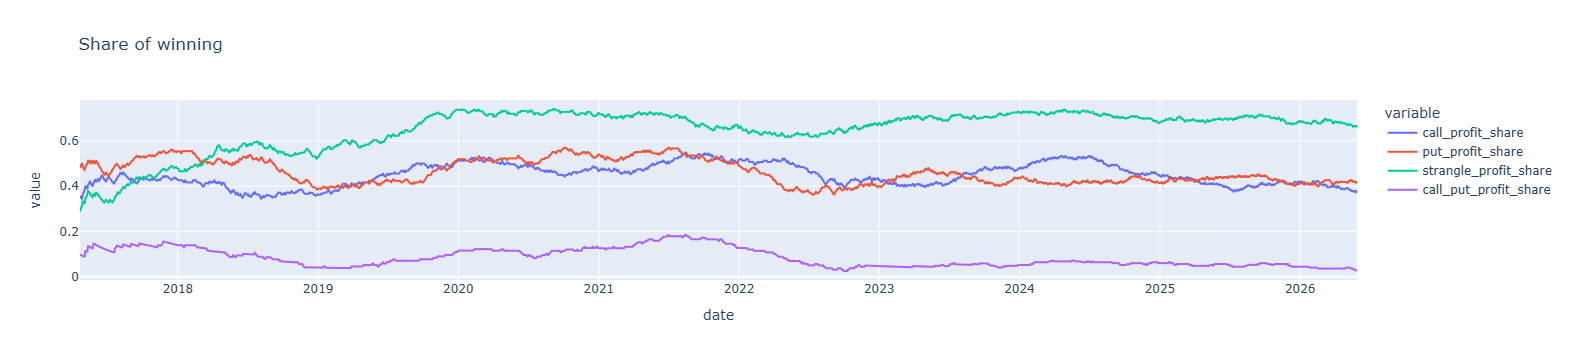

In [31]:
px.line(
    df_roll[['call_profit_share', 'put_profit_share', 'strangle_profit_share', 'call_put_profit_share']].iloc[30:],
    title='Share of winning'
)

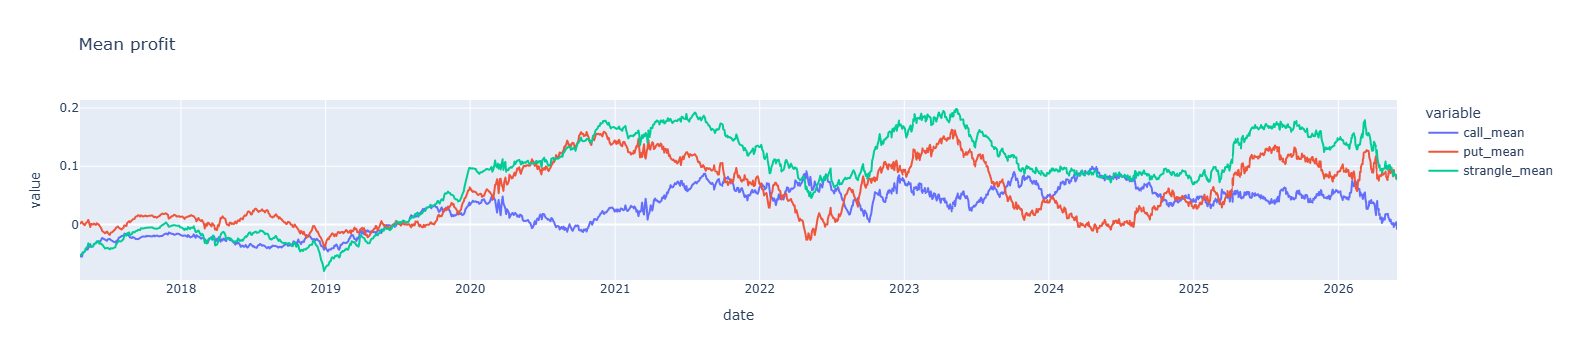

In [33]:
px.line(df_roll[['call_mean', 'put_mean', 'strangle_mean']].iloc[30:], title='Mean profit')

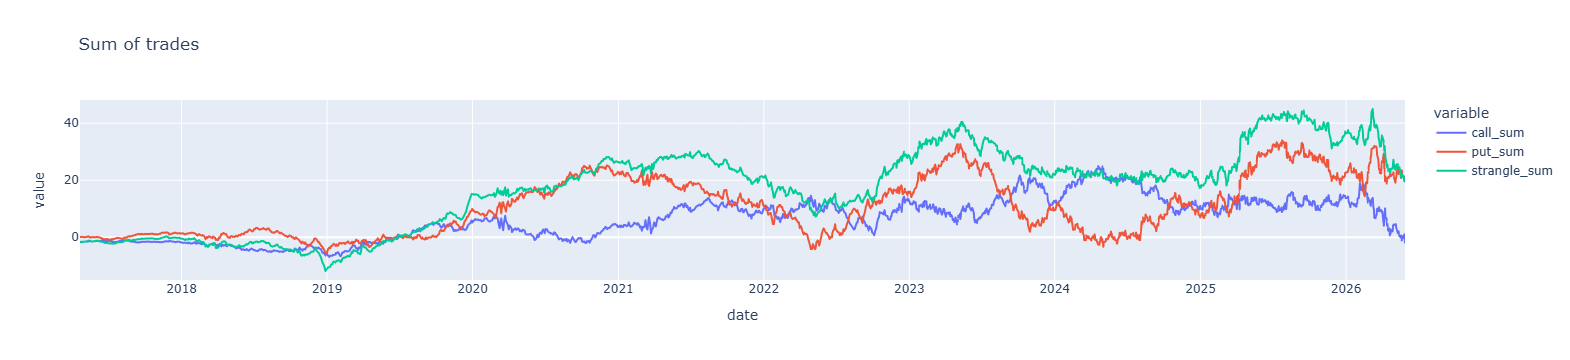

In [35]:
px.line(df_roll[['call_sum', 'put_sum', 'strangle_sum']].iloc[30:], title='Sum of trades')

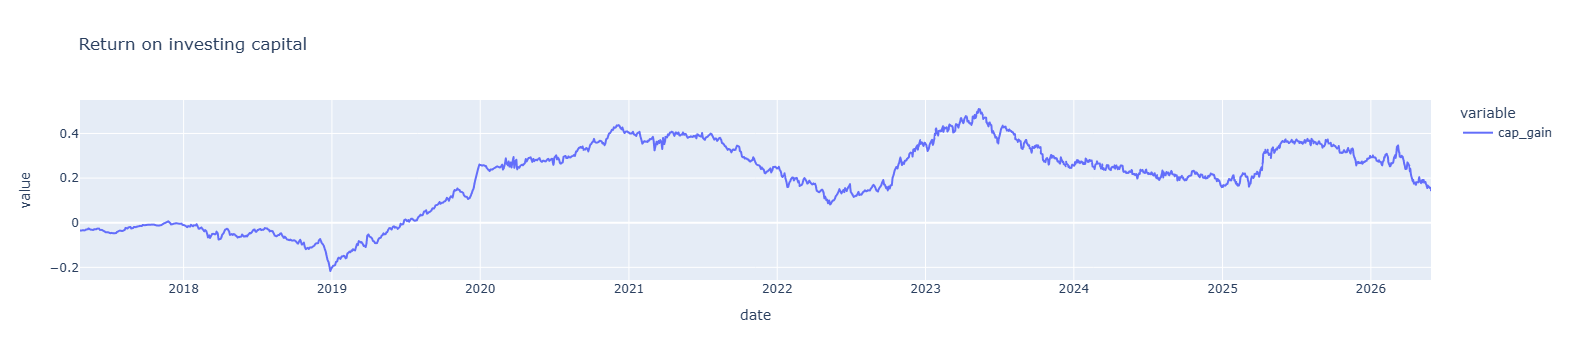

In [37]:
px.line(df_roll[['cap_gain']].iloc[30:], title='Return on investing capital')

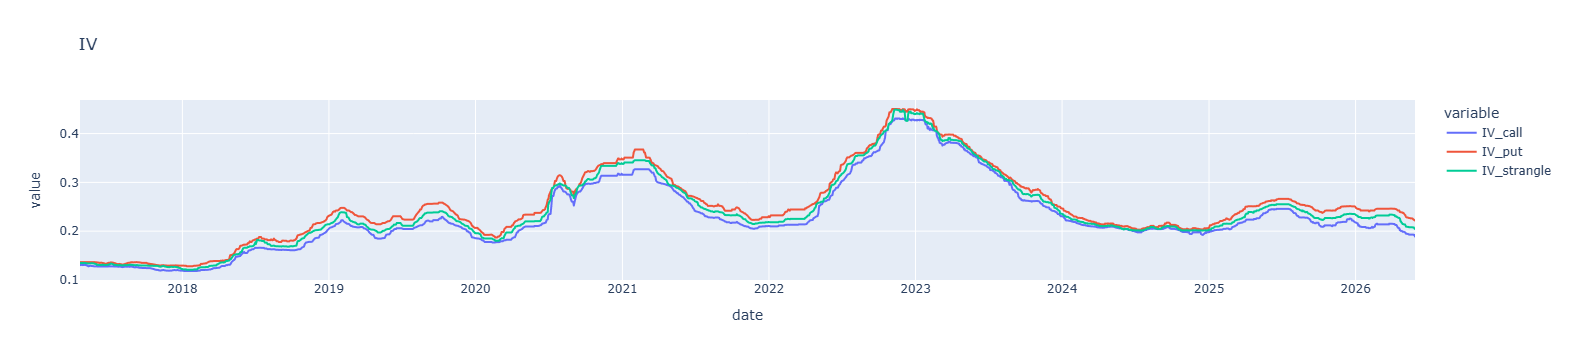

In [39]:
px.line(df_roll[['IV_call', 'IV_put', 'IV_strangle']].iloc[30:], title='IV')

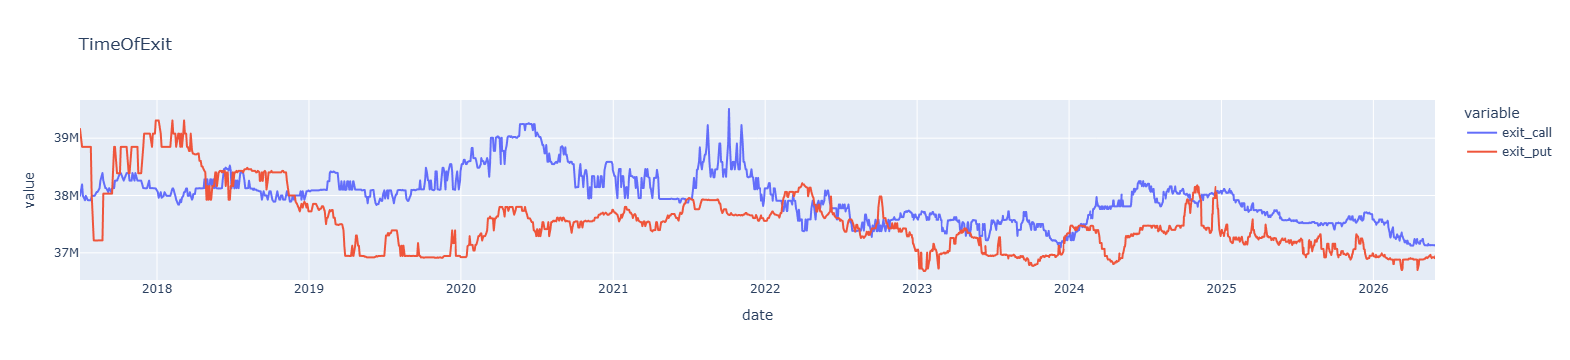

In [41]:
px.line(df_roll[['exit_call', 'exit_put']].iloc[50:], title='TimeOfExit')

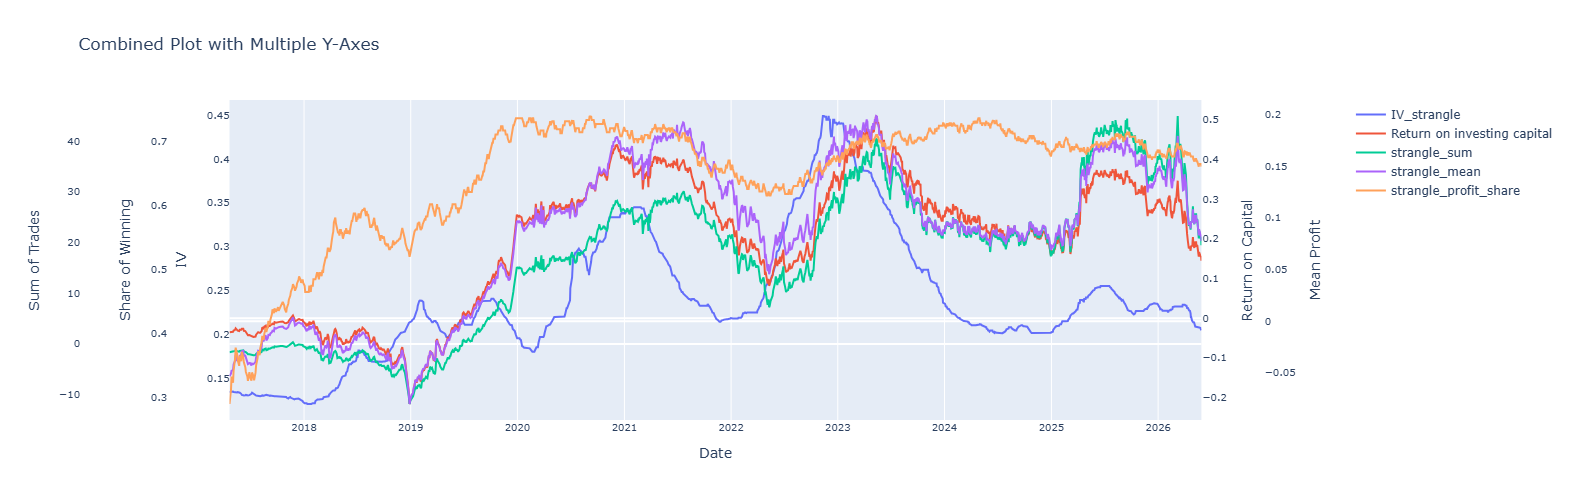

In [43]:
import plotly.graph_objects as go

cur_df = df_roll.iloc[30:]
fig = go.Figure()

fig.add_trace(go.Scatter(y=cur_df['IV_strangle'], x=cur_df.index, name='IV_strangle', yaxis='y1'))
fig.add_trace(go.Scatter(y=cur_df['cap_gain'], x=cur_df.index, name='Return on investing capital', yaxis='y2'))
fig.add_trace(go.Scatter(y=cur_df['strangle_sum'], x=cur_df.index, name='strangle_sum', yaxis='y3'))
fig.add_trace(go.Scatter(y=cur_df['strangle_mean'], x=cur_df.index, name='strangle_mean', yaxis='y4'))
fig.add_trace(go.Scatter(y=cur_df['strangle_profit_share'], x=cur_df.index, name='strangle_profit_share', yaxis='y5'))

fig.update_layout(
    title='Combined Plot with Multiple Y-Axes',
    height=500,
    xaxis=dict(title='Date', domain=[0.12, 0.9], tickfont=dict(size=10)),
    yaxis=dict(title='IV', side='left',  position=0.12, showgrid=False, tickfont=dict(size=10)),
    yaxis2=dict(title='Return on Capital', overlaying='y', side='right', position=0.9, showgrid=False, tickfont=dict(size=10)),
    yaxis3=dict(title='Sum of Trades', overlaying='y', side='left', anchor='free', position=0.00, showgrid=False, tickfont=dict(size=10)),
    yaxis4=dict(title='Mean Profit', overlaying='y', side='right', anchor='free', position=0.95, showgrid=False, tickfont=dict(size=10)),
    yaxis5=dict(title='Share of Winning', overlaying='y', side='left', anchor='free', position=0.07, showgrid=False, tickfont=dict(size=10))
)
fig.show()

# Time

In [45]:
print(
    '\n',np.quantile(strangle_trades['ext_time_ms'].dropna(), np.arange(0, 1.1, 0.1)),
    '\n',np.quantile(strangle_trades['ext_time_ms_put'].dropna(), np.arange(0, 1.1, 0.1))
)


 [34669588.         35331947.6        35818763.2        36198658.2
 36916326.4        37800241.5        39088366.6        41106988.1
 45232677.40000001 51546585.2        57612554.        ] 
 [34718228.         35258568.4        35602074.         36060788.6
 36589849.4        37349971.         38452949.6        40450581.2
 44236575.40000001 50032078.6        57597833.        ]


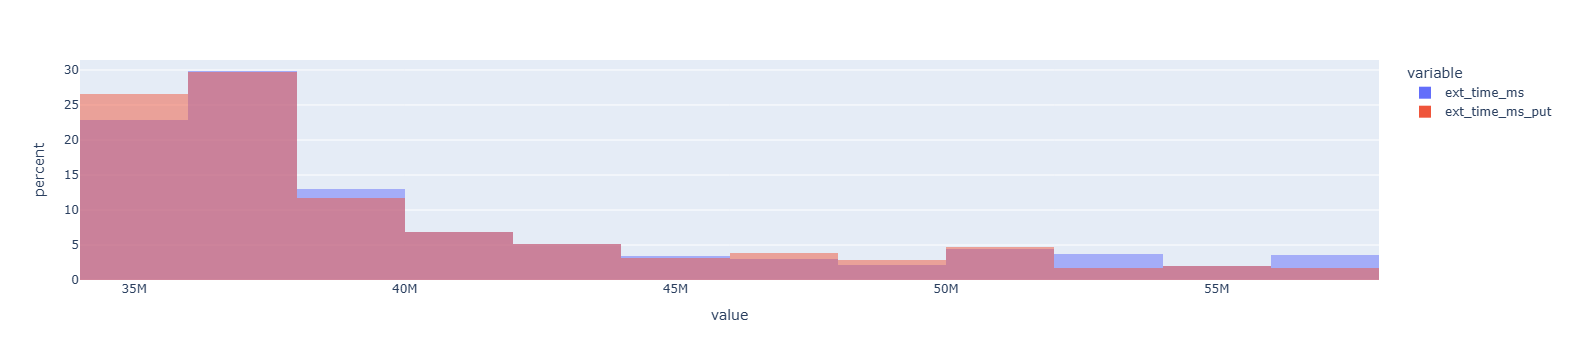

In [47]:
cur_df = pd.DataFrame(data=[strangle_trades['ext_time_ms'].dropna().to_list(), strangle_trades['ext_time_ms_put'].dropna().to_list()]).T
cur_df.columns = ['ext_time_ms', 'ext_time_ms_put']
px.histogram(cur_df.melt(), x="value", color="variable", nbins=20, opacity=0.5, width=1000, histnorm='percent', barmode='overlay')

# IV

In [49]:
strangle_trades['ext_time_ms'] = strangle_trades['ext_time_ms'].fillna(0)
strangle_trades['ext_time_ms_put'] = strangle_trades['ext_time_ms_put'].fillna(0)

strangle_trades['spread'] = (strangle_trades['ent_opt_ask'] - strangle_trades['ent_opt_bid']) / strangle_trades['ent_opt_ask']
strangle_trades['spread_put'] = (strangle_trades['ent_opt_ask_put'] - strangle_trades['ent_opt_bid_put']) / strangle_trades['ent_opt_ask_put']
strangle_trades['spread_avg'] = (strangle_trades['spread'] + strangle_trades['spread_put']) / 2

In [55]:
groups = pd.qcut(strangle_trades['IV_bid'], q=np.arange(0, 1.1, 0.1))
cur_box = strangle_trades.groupby(groups).agg(
    mean=('call_profit', 'mean'),
    median=('call_profit', 'median'),
    sum=('call_profit', 'sum'),
    count=('call_profit', len),
    positive_count=('call_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\938928027.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
IV_bid,,,,,,,
"(0.0603, 0.132]",0.002514,0.000000,0.440000,175,86,0.491429,0.002514
"(0.132, 0.156]",0.027759,-0.035000,4.830000,174,83,0.477011,0.027759
"(0.156, 0.178]",0.060920,0.030000,10.600000,174,88,0.505747,0.060920
"(0.178, 0.199]",0.011086,-0.100000,1.940000,175,82,0.468571,0.011086
"(0.199, 0.221]",0.056322,-0.045000,9.800000,174,82,0.471264,0.056322
"(0.221, 0.259]",0.068908,-0.120000,11.990000,174,76,0.436782,0.068908
"(0.259, 0.299]",0.083943,-0.150000,14.690000,175,79,0.451429,0.083943
"(0.299, 0.351]",0.032414,-0.190000,5.640000,174,69,0.396552,0.032414
"(0.351, 0.452]",0.020115,-0.230000,3.500000,174,64,0.367816,0.020115


In [59]:
groups = pd.qcut(strangle_trades['IV_bid_put'], q=np.arange(0, 1.1, 0.1))
cur_box = strangle_trades.groupby(groups).agg(
   mean=('put_profit', 'mean'),
    median=('put_profit', 'median'),
    sum=('put_profit', 'sum'),
    count=('put_profit', len),
    positive_count=('put_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\1014588524.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
IV_bid_put,,,,,,,
"(0.0726, 0.149]",0.026629,0.070000,4.660000,175,92,0.525714,0.026629
"(0.149, 0.175]",0.068621,0.075000,11.940000,174,91,0.522989,0.068621
"(0.175, 0.194]",-0.020517,-0.175000,-3.570000,174,67,0.385057,-0.020517
"(0.194, 0.218]",0.032914,-0.120000,5.760000,175,79,0.451429,0.032914
"(0.218, 0.247]",0.034540,-0.110000,6.010000,174,79,0.454023,0.034540
"(0.247, 0.278]",0.076609,-0.095000,13.330000,174,81,0.465517,0.076609
"(0.278, 0.322]",0.084057,-0.190000,14.710000,175,77,0.440000,0.084057
"(0.322, 0.372]",0.083736,-0.225000,14.570000,174,74,0.425287,0.083736
"(0.372, 0.484]",0.116207,-0.170000,20.220000,174,79,0.454023,0.116207


In [63]:
groups = pd.qcut(strangle_trades['avgIV'], q=np.arange(0, 1.1, 0.1))
cur_box = strangle_trades.groupby(groups).agg(
   mean=('strangle_profit', 'mean'),
    median=('strangle_profit', 'median'),
    sum=('strangle_profit', 'sum'),
    count=('strangle_profit', len),
    positive_count=('strangle_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\3866229010.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
avgIV,,,,,,,
"(0.0664, 0.142]",0.044457,0.040000,7.780000,175,107,0.611429,0.044457
"(0.142, 0.165]",0.089023,0.100000,15.490000,174,115,0.660920,0.089023
"(0.165, 0.187]",0.072184,0.095000,12.560000,174,122,0.701149,0.072184
"(0.187, 0.209]",0.077600,0.120000,13.580000,175,114,0.651429,0.077600
"(0.209, 0.233]",0.115920,0.165000,20.170000,174,123,0.706897,0.115920
"(0.233, 0.269]",0.083046,0.185000,14.450000,174,119,0.683908,0.083046
"(0.269, 0.311]",0.143714,0.230000,25.150000,175,124,0.708571,0.143714
"(0.311, 0.36]",0.147011,0.295000,25.580000,174,125,0.718391,0.147011
"(0.36, 0.468]",0.105345,0.280000,18.330000,174,116,0.666667,0.105345


# Spreads

In [65]:
groups = pd.qcut(strangle_trades['spread'], q=np.arange(0, 1.1, 0.1), duplicates='drop')
cur_box = strangle_trades.groupby(groups).agg(
   mean=('call_profit', 'mean'),
    median=('call_profit', 'median'),
    sum=('call_profit', 'sum'),
    count=('call_profit', len),
    positive_count=('call_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\2446813767.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
spread,,,,,,,
"(-0.137, 0.00962]",0.092747,-0.250000,16.880000,182,70,0.384615,0.092747
"(0.00962, 0.0119]",0.103452,-0.170000,17.380000,168,66,0.392857,0.103452
"(0.0119, 0.0143]",-0.026647,-0.210000,-4.610000,173,65,0.375723,-0.026647
"(0.0143, 0.0164]",0.028152,-0.190000,5.180000,184,75,0.407609,0.028152
"(0.0164, 0.0192]",0.036242,-0.160000,5.980000,165,71,0.430303,0.036242
"(0.0192, 0.0222]",0.056865,-0.020000,10.520000,185,91,0.491892,0.056865
"(0.0222, 0.0274]",0.006807,-0.030000,1.130000,166,80,0.481928,0.006807
"(0.0274, 0.0382]",0.035988,-0.015000,6.190000,172,83,0.482558,0.035988
"(0.0382, 0.0586]",0.006264,-0.005000,1.090000,174,86,0.494253,0.006264


In [69]:
groups = pd.qcut(strangle_trades['spread_put'], q=np.arange(0, 1.1, 0.1), duplicates='drop')
cur_box = strangle_trades.groupby(groups).agg(
   mean=('put_profit', 'mean'),
    median=('put_profit', 'median'),
    sum=('put_profit', 'sum'),
    count=('put_profit', len),
    positive_count=('put_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\2289423444.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
spread_put,,,,,,,
"(-0.0501, 0.00901]",0.130495,-0.365000,23.750000,182,72,0.395604,0.130495
"(0.00901, 0.0111]",0.050983,-0.240000,8.820000,173,70,0.404624,0.050983
"(0.0111, 0.013]",0.038571,-0.250000,6.750000,175,67,0.382857,0.038571
"(0.013, 0.0149]",0.090114,-0.130000,15.770000,175,79,0.451429,0.090114
"(0.0149, 0.0173]",0.070595,-0.170000,11.860000,168,74,0.440476,0.070595
"(0.0173, 0.0204]",0.088297,-0.070000,16.070000,182,87,0.478022,0.088297
"(0.0204, 0.0256]",0.061310,-0.020000,10.300000,168,83,0.494048,0.061310
"(0.0256, 0.0345]",0.091630,0.040000,16.860000,184,93,0.505435,0.091630
"(0.0345, 0.05]",-0.014036,-0.045000,-2.330000,166,74,0.445783,-0.014036


In [71]:
groups = pd.qcut(strangle_trades['spread_avg'], q=np.arange(0, 1.1, 0.1))
cur_box = strangle_trades.groupby(groups).agg(
   mean=('strangle_profit', 'mean'),
    median=('strangle_profit', 'median'),
    sum=('strangle_profit', 'sum'),
    count=('strangle_profit', len),
    positive_count=('strangle_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\3378715126.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
spread_avg,,,,,,,
"(-0.0909, 0.00989]",0.141657,0.390000,24.790000,175,109,0.622857,0.141657
"(0.00989, 0.012]",0.164310,0.370000,28.590000,174,122,0.701149,0.164310
"(0.012, 0.014]",0.100000,0.235000,17.400000,174,116,0.666667,0.100000
"(0.014, 0.0162]",0.142343,0.250000,24.910000,175,127,0.725714,0.142343
"(0.0162, 0.0186]",0.072000,0.180000,12.600000,175,125,0.714286,0.072000
"(0.0186, 0.0218]",0.061272,0.120000,10.600000,173,115,0.664740,0.061272
"(0.0218, 0.0267]",0.135543,0.180000,23.720000,175,134,0.765714,0.135543
"(0.0267, 0.0361]",0.111322,0.130000,19.370000,174,120,0.689655,0.111322
"(0.0361, 0.0528]",0.068793,0.080000,11.970000,174,117,0.672414,0.068793


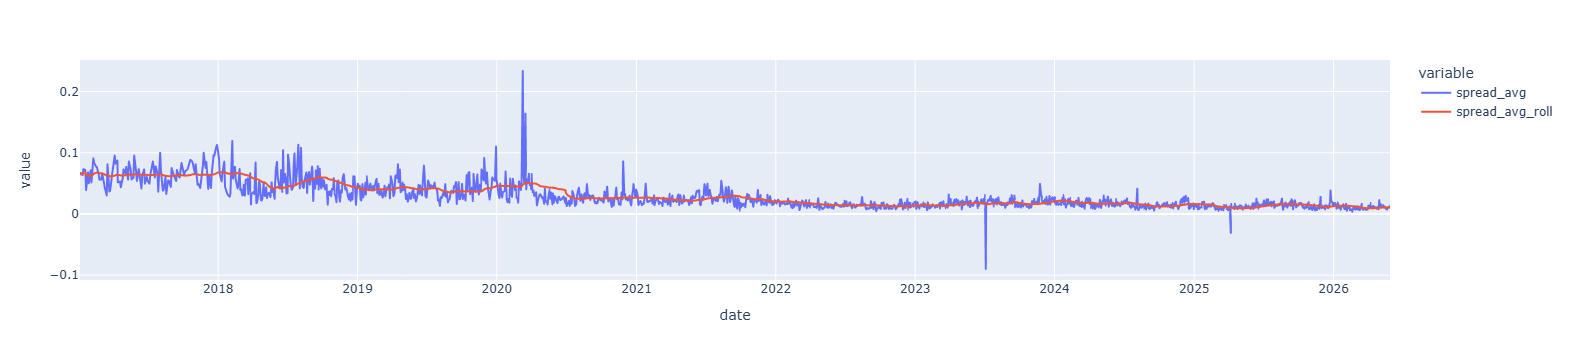

In [73]:
strangle_trades['spread_avg_roll'] = strangle_trades['spread_avg'].rolling(50, min_periods=1).mean()

px.line(strangle_trades[['spread_avg', 'spread_avg_roll']])

# Premium to price

In [75]:
strangle_trades['premium_to_baPrice'] = (
        strangle_trades[['ent_opt_bid', 'ent_opt_bid_put']].sum(axis=1) /
        strangle_trades[['strike', 'strike_put']].mean(axis=1)
)

In [79]:
groups = pd.qcut(strangle_trades['premium_to_baPrice'], q=np.arange(0, 1.1, 0.1))
cur_box = strangle_trades.groupby(groups).agg(
   mean=('strangle_profit', 'mean'),
    median=('strangle_profit', 'median'),
    sum=('strangle_profit', 'sum'),
    count=('strangle_profit', len),
    positive_count=('strangle_profit', lambda x: (x > 0).sum()),
)
cur_box['bin_profit'] = cur_box['positive_count'] / cur_box['count']
cur_box['day_profit'] = cur_box['sum'] / cur_box['count']
cur_box.style.background_gradient(cmap='RdYlGn', axis=0)

C:\Users\alexa\AppData\Local\Temp\ipykernel_81136\2823820331.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,mean,median,sum,count,positive_count,bin_profit,day_profit
premium_to_baPrice,,,,,,,
"(-0.000365, 0.00152]",0.044114,0.010000,7.720000,175,93,0.531429,0.044114
"(0.00152, 0.00186]",0.066494,0.075000,11.570000,174,121,0.695402,0.066494
"(0.00186, 0.00216]",0.106322,0.115000,18.500000,174,128,0.735632,0.106322
"(0.00216, 0.00246]",0.092914,0.130000,16.260000,175,117,0.668571,0.092914
"(0.00246, 0.00284]",0.087069,0.160000,15.150000,174,124,0.712644,0.087069
"(0.00284, 0.00333]",0.121207,0.195000,21.090000,174,122,0.701149,0.121207
"(0.00333, 0.00393]",0.082914,0.220000,14.510000,175,118,0.674286,0.082914
"(0.00393, 0.00458]",0.167931,0.330000,29.220000,174,127,0.729885,0.167931
"(0.00458, 0.00596]",0.046229,0.280000,8.090000,175,113,0.645714,0.046229
